## Step 1: Load the Training Split Only
We work exclusively on the training split during EDA, to avoid any information from validation/test leaking into our analysis or feature decisions.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("artifacts/train.csv", parse_dates=[
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
])

print(f"Train shape: {train.shape}")
train.head()

Train shape: (69608, 21)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,customer_state,n_items,total_price,total_freight,total_payment_value,n_payments,max_installments,review_score,n_reviews,is_late
0,2e7a8482f6fb09756ca50c10d7bfc047,08c5351a6aca1c1589a38f244edeee9d,shipped,2016-09-04 21:15:19,2016-10-07 13:18:03,2016-10-18 13:14:51,NaT,2016-10-20,b7d76e111c89f7ebf14761390f0f7d17,69309,...,RR,2.0,72.89,63.34,136.23,1.0,1.0,1.0,1.0,NaN
1,e5fa5a7210941f7d56d0208e4e071d35,683c54fc24d40ee9f8a6fc179fd9856c,canceled,2016-09-05 00:15:34,2016-10-07 13:17:15,NaT,NaT,2016-10-28,4854e9b3feff728c13ee5fc7d1547e92,99025,...,RS,1.0,59.50,15.56,75.06,1.0,3.0,1.0,1.0,NaN
2,809a282bbd5dbcabb6f2f724fca862ec,622e13439d6b5a0b486c435618b2679e,canceled,2016-09-13 15:24:19,2016-10-07 13:16:46,NaT,NaT,2016-09-30,009b0127b727ab0ba422f6d9604487c7,12244,...,SP,NaN,NaN,NaN,40.95,1.0,2.0,1.0,1.0,NaN
3,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,830d5b7aaa3b6f1e9ad63703bec97d23,14600,...,SP,3.0,134.97,8.49,NaN,NaN,NaN,1.0,1.0,1.0
4,71303d7e93b399f5bcd537d124c0bcfa,b106b360fe2ef8849fbbd056f777b4d5,canceled,2016-10-02 22:07:52,2016-10-06 15:50:56,NaT,NaT,2016-10-25,0eb1ee9dba87f5b36b4613a65074337c,2975,...,SP,1.0,100.00,9.34,109.34,1.0,1.0,1.0,1.0,NaN


## Step 2: Data Types, Shape, and Memory
Understand which columns are numerical, categorical, date, text, or ID before doing any deeper analysis.

In [4]:
print(train.dtypes)
print()
print(f"Memory usage: {train.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
customer_unique_id                       object
customer_zip_code_prefix                  int64
customer_city                            object
customer_state                           object
n_items                                 float64
total_price                             float64
total_freight                           float64
total_payment_value                     float64
n_payments                              float64
max_installments                        float64
review_score                            float64
n_reviews                               float64
is_late                                 

## Step 3: Missing Values
Check how many values are missing per column, and whether the missingness itself is meaningful (e.g., orders that were never delivered).

In [5]:
missing = train.isna().sum()
missing_pct = (missing / len(train)) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct.round(2)
}).sort_values("missing_pct", ascending=False)

missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_pct
is_late,2386,3.43
order_delivered_customer_date,2380,3.42
order_delivered_carrier_date,1456,2.09
n_items,647,0.93
total_price,647,0.93
total_freight,647,0.93
review_score,608,0.87
n_reviews,608,0.87
order_approved_at,86,0.12
total_payment_value,1,0.00


## Step 3b: Investigate Orders Missing Item Data
647 orders have no matching rows in order_items. Check their order_status to understand why.

In [6]:
missing_items = train[train["n_items"].isna()]
print(missing_items["order_status"].value_counts())

order_status
unavailable    555
canceled        84
created          5
invoiced         2
shipped          1
Name: count, dtype: int64


## Step 4: Numerical Columns — Statistics and Distributions
Look at summary statistics for numerical columns, and check for outliers or values that don't make sense (e.g., negative prices, zero items).

In [7]:
numerical_cols = ["n_items", "total_price", "total_freight", "total_payment_value", 
                   "n_payments", "max_installments", "review_score", "n_reviews"]

train[numerical_cols].describe()

,n_items,total_price,total_freight,total_payment_value,n_payments,max_installments,review_score,n_reviews
count,68961.000000,68961.000000,68961.000000,69607.000000,69607.000000,69607.000000,69000.000000,69000.000000
mean,1.141486,136.615566,22.288178,159.257369,1.048257,2.979499,4.022314,1.007348
std,0.541285,206.374262,20.077747,216.625471,0.412692,2.759644,1.385458,0.086081
min,1.000000,2.290000,0.000000,10.070000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,45.900000,14.100000,61.720000,1.000000,1.000000,4.000000,1.000000
50%,1.000000,85.500000,16.790000,104.350000,1.000000,2.000000,5.000000,1.000000
75%,1.000000,149.900000,23.700000,175.870000,1.000000,4.000000,5.000000,1.000000
max,21.000000,13440.000000,1002.290000,13664.080000,29.000000,24.000000,5.000000,3.000000


## Step 4b: Investigate Zero Freight and Extreme Prices
Check how many orders have zero freight value, and look at the most expensive orders to see if they make sense.

In [8]:
zero_freight = (train["total_freight"] == 0).sum()
print(f"Orders with zero freight: {zero_freight}")

print("\nTop 5 most expensive orders:")
print(train.nlargest(5, "total_price")[["order_id", "n_items", "total_price", "total_freight", "order_status"]])

Orders with zero freight: 10

Top 5 most expensive orders:
                               order_id  n_items  total_price  total_freight  \
27409  03caa2c082116e1d31e67e9ae3700499      8.0      13440.0         224.08   
2004   0812eb902a67711a1cb742b3cdaa65ae      1.0       6735.0         194.31   
10884  f5136e38d1a14a4dbd87dff67da82701      1.0       6499.0         227.66   
36637  2cc9089445046817a7539d90805e6e5a      6.0       5934.6         146.94   
5625   a96610ab360d42a2e5335a3998b4718a      1.0       4799.0         151.34   

      order_status  
27409    delivered  
2004     delivered  
10884    delivered  
36637    delivered  
5625     delivered  


## Step 5: Categorical Columns
Check value counts and cardinality for categorical columns like order_status and customer_state.

In [9]:
print("order_status value counts:")
print(train["order_status"].value_counts())

print(f"\ncustomer_state: {train['customer_state'].nunique()} unique values")
print(train["customer_state"].value_counts().head(10))

print(f"\ncustomer_city: {train['customer_city'].nunique()} unique values")

order_status value counts:
order_status
delivered      67224
shipped          855
unavailable      561
canceled         429
processing       290
invoiced         242
created            5
approved           2
Name: count, dtype: int64

customer_state: 27 unique values
customer_state
SP    28019
RJ     9343
MG     8333
RS     3997
PR     3545
SC     2645
BA     2400
ES     1468
GO     1456
DF     1444
Name: count, dtype: int64

customer_city: 3780 unique values


## Step 6: Relationship Between Features and the Label
Check how late-delivery rate varies by customer state, and by numerical features like total_price and n_items.

In [10]:
# Late delivery rate by state (top 10 states by order count)
top_states = train["customer_state"].value_counts().head(10).index

late_by_state = train[train["customer_state"].isin(top_states)].groupby("customer_state")["is_late"].mean().sort_values(ascending=False) * 100

print("Late delivery rate (%) by state:")
print(late_by_state.round(2))

Late delivery rate (%) by state:
customer_state
RJ    16.63
BA    15.01
ES    13.22
SC    12.01
GO     9.62
RS     8.68
DF     8.03
MG     6.30
SP     5.61
PR     5.43
Name: is_late, dtype: float64


## Step 6b: Late Delivery Rate by Price and Item Count
Check if larger or more expensive orders are more likely to be late.

In [11]:
# Bin total_price into quartiles and check late rate per bin
train["price_bin"] = pd.qcut(train["total_price"], q=4, labels=["Low", "Medium", "High", "Very High"])
print("Late rate by price bin:")
print(train.groupby("price_bin", observed=True)["is_late"].mean().round(3) * 100)

print("\nLate rate by number of items:")
print(train.groupby("n_items", observed=True)["is_late"].mean().round(3).head(10) * 100)

Late rate by price bin:
price_bin
Low           7.9
Medium        8.8
High          9.2
Very High    10.2
Name: is_late, dtype: float64

Late rate by number of items:
n_items
1.0     9.2
2.0     7.5
3.0     6.9
4.0     6.7
5.0     9.0
6.0     8.0
7.0     0.0
8.0     0.0
9.0     0.0
10.0    0.0
Name: is_late, dtype: float64


## Step 6c: Add Sample Size to Avoid Misleading Percentages
The 0% late rate for n_items 7–10 is likely due to a very small sample size, not a real pattern. Add counts to check.

In [12]:
items_summary = train.groupby("n_items", observed=True)["is_late"].agg(["mean", "count"])
items_summary["mean"] = (items_summary["mean"] * 100).round(2)
print(items_summary.head(12))

         mean  count
n_items             
1.0      9.24  60502
2.0      7.48   5173
3.0      6.90    898
4.0      6.67    360
5.0      9.02    133
6.0      7.96    113
7.0      0.00     13
8.0      0.00      8
9.0      0.00      3
10.0     0.00      6
11.0     0.00      3
12.0     0.00      2


## Step 7: Date Analysis — Delivery Time and Seasonality
Compute actual delivery duration, and check for monthly/weekday patterns in the late-delivery rate.

In [13]:
# Delivery duration in days (only for delivered orders)
train["delivery_days"] = (train["order_delivered_customer_date"] - train["order_purchase_timestamp"]).dt.days

print("Delivery days statistics:")
print(train["delivery_days"].describe())

# Late rate by month
train["order_month"] = train["order_purchase_timestamp"].dt.to_period("M")
monthly_late = train.groupby("order_month", observed=True)["is_late"].agg(["mean", "count"])
monthly_late["mean"] = (monthly_late["mean"] * 100).round(2)
print("\nLate rate by month:")
print(monthly_late)

Delivery days statistics:
count    67228.000000
mean        13.363286
std         10.254740
min          0.000000
25%          7.000000
50%         11.000000
75%         17.000000
max        209.000000
Name: delivery_days, dtype: float64

Late rate by month:
               mean  count
order_month               
2016-09      100.00      1
2016-10        1.13    265
2016-12        0.00      1
2017-01        3.07    750
2017-02        3.21   1653
2017-03        5.58   2546
2017-04        7.86   2303
2017-05        3.61   3545
2017-06        3.86   3135
2017-07        3.43   3872
2017-08        3.32   4193
2017-09        5.20   4150
2017-10        5.29   4478
2017-11       14.31   7288
2017-12        8.38   5513
2018-01        6.56   7069
2018-02       15.99   6555
2018-03       21.36   7003
2018-04        6.65   2902


## Step 7b: Investigate the 209-Day Delivery Outlier
Check the order with the extreme 209-day delivery time to understand if it's a data error or a real edge case.

In [14]:
extreme = train.nlargest(3, "delivery_days")[
    ["order_id", "order_purchase_timestamp", "order_delivered_customer_date", 
     "order_estimated_delivery_date", "delivery_days", "customer_state", "is_late"]
]
print(extreme)

                               order_id order_purchase_timestamp  \
2535   ca07593549f1816d26a572e06dc1eab6      2017-02-21 23:31:27   
57992  1b3190b2dfa9d789e1f14c05b647a14a      2018-02-23 14:57:35   
3494   440d0d17af552815d15a9e41abe49359      2017-03-07 23:59:51   

      order_delivered_customer_date order_estimated_delivery_date  \
2535            2017-09-19 14:36:39                    2017-03-22   
57992           2018-09-19 23:24:07                    2018-03-15   
3494            2017-09-19 15:12:50                    2017-04-07   

       delivery_days customer_state  is_late  
2535           209.0             ES      1.0  
57992          208.0             RJ      1.0  
3494           195.0             PA      1.0  


## Step 8: Visualize Key Findings
Create charts summarizing the most important patterns found: late rate by state, and late rate by month.

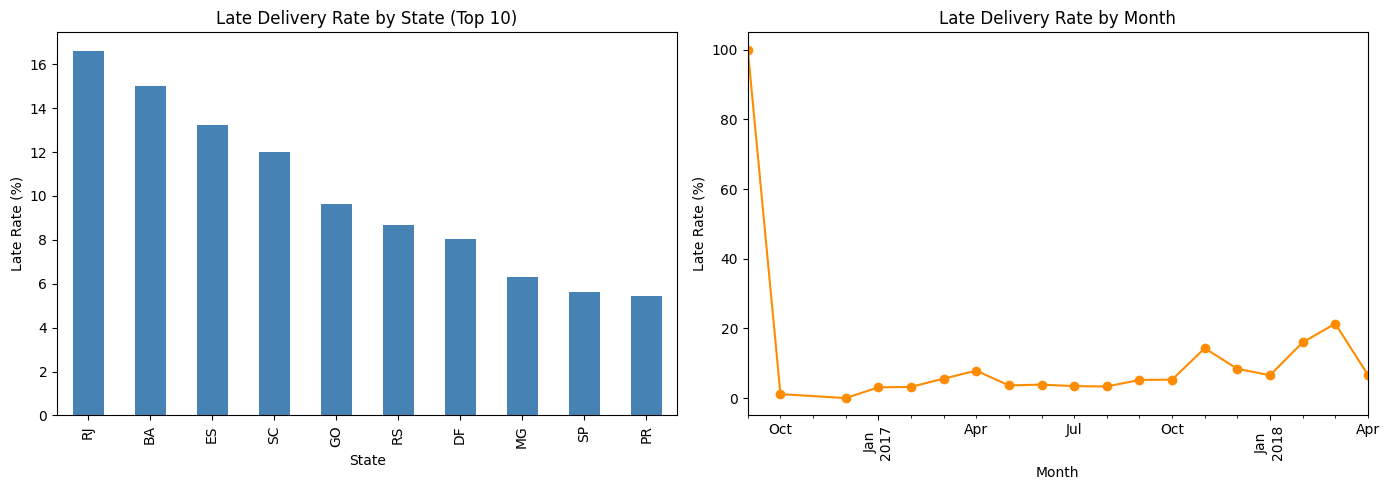

✅ Saved eda_findings.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Late rate by state
late_by_state.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Late Delivery Rate by State (Top 10)")
axes[0].set_ylabel("Late Rate (%)")
axes[0].set_xlabel("State")

# Chart 2: Late rate by month
monthly_late["mean"].plot(kind="line", marker="o", ax=axes[1], color="darkorange")
axes[1].set_title("Late Delivery Rate by Month")
axes[1].set_ylabel("Late Rate (%)")
axes[1].set_xlabel("Month")
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.savefig("artifacts/eda_findings.png", dpi=100)
plt.show()

print("✅ Saved eda_findings.png")

## Step 9: Findings Summary

**Key EDA findings:**
1. **Class imbalance confirmed**: ~92% on-time, ~8% late orders.
2. **Geographic effect is strong**: late rate ranges from 5.4% (PR) to 16.6% (RJ) — customer_state will be an important feature.
3. **Price effect**: higher-value orders have a slightly higher late rate (7.9% → 10.2% from low to very-high price quartile).
4. **Item count**: most orders (87%) have exactly 1 item; late rate patterns for orders with 7+ items are unreliable due to tiny sample sizes (2-13 orders).
5. **Strong seasonality**: late rate spiked sharply in Feb-Mar 2018 (16-21%) compared to most of 2017 (3-7%) — this explains the train/val label imbalance difference seen in Notebook 3.
6. **Data quality notes**:
   - 647 orders have no order_items data — mostly "unavailable" or "canceled" status, expected behavior.
   - A few extreme delivery delays exist (up to 209 days) — real cases, not data errors, all correctly labeled as late.
   - 10 orders have zero freight value — rare, likely free shipping promotions.

**Decisions for the next notebooks:**
- Use `customer_state` as a key feature (high signal).
- Consider a time-based or seasonal feature (e.g., order month) given the strong seasonality found.
- Use `total_price`, `n_items` as numerical features.
- `customer_city` has very high cardinality (3,780 values) — avoid one-hot encoding directly; consider dropping or grouping rare cities.
- Given the class imbalance (~92/8), use metrics like F1, precision/recall, or ROC-AUC instead of accuracy in Notebook 6.

In [17]:
findings = """
EDA Findings Summary - Notebook 4
===================================

1. Class imbalance confirmed: ~92% on-time, ~8% late orders.
2. Geographic effect is strong: late rate ranges from 5.4% (PR) to 16.6% (RJ).
3. Price effect: higher-value orders have slightly higher late rate (7.9% -> 10.2%).
4. Item count: most orders (87%) have exactly 1 item; patterns for 7+ items unreliable (tiny samples).
5. Strong seasonality: late rate spiked in Feb-Mar 2018 (16-21%) vs most of 2017 (3-7%).
6. Data quality notes:
   - 647 orders have no order_items data (mostly unavailable/canceled) - expected.
   - Extreme delivery delays exist (up to 209 days) - real cases, correctly labeled.
   - 10 orders have zero freight value - rare, likely free shipping.

Decisions for next notebooks:
- Use customer_state as a key feature.
- Consider order month / seasonal feature.
- Use total_price, n_items as numerical features.
- customer_city has high cardinality (3,780) - avoid direct one-hot encoding.
- Use F1/precision/recall/ROC-AUC instead of accuracy due to class imbalance.
"""

with open("artifacts/eda_findings.txt", "w") as f:
    f.write(findings)

print("✅ Saved eda_findings.txt")

✅ Saved eda_findings.txt
